Notebook for reproducing Shreyas' scaling results. This notebook is doing weak scaling, with the number of nodes used equal to the number of nodes traced. 

# 0. Set Up Environment, Container, Experiment Parameters

In [16]:
import subprocess
import time
import re
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import os
import workflows
import json
import glob
from plotnine import *
import humanfriendly

## User Parameters Here

In [17]:
# === Environment Setup ===

e4s_cl_path = '/lus/bnchlu1/neth/e4s-cl/install/bin'
go_dir = '/lus/scratch/crickett/go/'
apptainer_bin_path = '/lus/scratch/crickett/software/usr/bin'
apptainer_cache_dir = '/lus/bnchlu1/neth/.local/apptainer/'

container_url = 'ghcr.io/hpc-ai-adv-dev/fastotf2/fastotf2-converter-libfabric2.3.1:pr-22'
entrypoint_path = '/workspace/fastotf2/apps/FastOTF2Converter/target/release/FastOTF2Converter_real'
container_name = 'fastotf2-converter-libfabric2.3.1-pr-22.sif'

# === Environment Defaults

trace_paths = {
    2:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-2-node-single-HPL-run/",
    4:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-4-node-single-HPL-run/",
    8:  "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-8-node-single-HPL-run/",
    16: "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-16-node-single-HPL-run/",
    32: "/lus/bnchlu1/adt/otf2-traces/frontier/frontier-32-node-single-HPL-run/",
}


# === Experiment Setup ===
strategies = ["locgroup_dist_block"]
formats =  ["PARQUET"]
thread_counts = [64] # Max seems to be 256
trial_count = 1
max_wait_s = 12 * 60 * 60
sort_callgraph_flags = [False] 

gib_per_node = 0.7
workflow_dir = os.getcwd()
output_dir = os.path.join(workflow_dir, f"out_{gib_per_node}gib_per_node")
logs_dir = os.path.join(output_dir, "logs")

## Environment

In [18]:
workflows.set_workflow_log(f'{workflow_dir}/workflow.log')
workflows.run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}')
for converter_node_count, trace_path in trace_paths.items():
    workflows.run_cmd(f'e4s-cl profile edit --add-files {trace_path}')

os.environ['APPTAINER_CACHEDIR'] = apptainer_cache_dir
os.environ["PATH"] += os.pathsep + go_dir + '/bin'
os.environ["LD_LIBRARY_PATH"] += os.pathsep + go_dir + '/lib'
os.environ["PATH"] += os.pathsep + apptainer_bin_path
os.environ["PATH"] += os.pathsep + e4s_cl_path

> e4s-cl profile edit --add-files /lus/bnchlu1/neth/fastotf2/workflows/scaling


File /lus/bnchlu1/neth/fastotf2/workflows/scaling already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/adt/otf2-traces/frontier/frontier-2-node-single-HPL-run/


File /lus/bnchlu1/adt/otf2-traces/frontier/frontier-2-node-single-HPL-run already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/adt/otf2-traces/frontier/frontier-4-node-single-HPL-run/


...

File /lus/bnchlu1/adt/otf2-traces/frontier/frontier-8-node-single-HPL-run already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/adt/otf2-traces/frontier/frontier-16-node-single-HPL-run/


File /lus/bnchlu1/adt/otf2-traces/frontier/frontier-16-node-single-HPL-run already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/adt/otf2-traces/frontier/frontier-32-node-single-HPL-run/


File /lus/bnchlu1/adt/otf2-traces/frontier/frontier-32-node-single-HPL-run already in profile's files


## Download Containers

In [19]:
workflows.print_and_log(f"Downloading container from {container_url}...")
container_name = workflows.download_custom_container(container_url)
#container_name = 'fastotf2-fastotf2-converter-ofi-latest.sif'
container_path = os.path.join(workflow_dir, container_name)

Container fastotf2-fastotf2-converter-libfabric2.3.1-pr-22.sif already exists, skipping download.


## Add the pre-execution script to e4s-cl

In [20]:
preexec_file_path = os.path.join(workflow_dir, 'e4s-cl-preexec.sh')
with open(preexec_file_path, 'w') as f:
    f.write('#!/bin/bash\n')
    f.write('export LD_LIBRARY_PATH="/opt/otf2/lib:${LD_LIBRARY_PATH}"\n')
    f.write('export CHPL_RT_MAX_HEAP_SIZE=50%\n')

workflows.run_cmd(f'e4s-cl profile edit --source {preexec_file_path}')

> e4s-cl profile edit --source /lus/bnchlu1/neth/fastotf2/workflows/scaling/e4s-cl-preexec.sh


# 1. Prepare Sweep

In [21]:
argsets = []
for sort_flag in sort_callgraph_flags:
    for strategy in strategies:
        for format in formats:
            for traced_node_count in trace_paths:
                trace_path = trace_paths[traced_node_count]
                for thread_count in thread_counts:
                    for trial in range(trial_count):
                        arg_map = {}

                        # get the output of a du to get the trace size
                        result = subprocess.run(['du', '-sh', trace_path], check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
                        result_str = result.stdout.decode('utf-8').strip()
                        trace_size = result_str.split()[0]
                        print(f'{trace_path} size: {trace_size}')

                        trace_size_bytes = humanfriendly.parse_size(trace_size)
                        trace_size_gib = trace_size_bytes / (1024 ** 3)
                        converter_node_count = max(1, int(trace_size_gib / gib_per_node)) # weaks scaling
                        arg_map['trace_size_gib'] = trace_size_gib
                        print(converter_node_count)
                        run_output_dir = os.path.join(output_dir, f'{strategy}_{format}_{converter_node_count}nodes_{thread_count}threads_{"sort" if sort_flag else "nosort"}_trial{trial}')
                        log_path = os.path.join(run_output_dir, 'logs')
                        log_file = os.path.join(log_path, 'converter.log')
                        e4s_cl_args = [f'--image={container_path}'
                                    ]

                        srun_args = [f'--nodes={converter_node_count}', 
                                    f'--ntasks-per-node=1',
                                    f'--cpus-per-task={thread_count}',
                                    f'--time=1:00:00', # one hour
                                    f'--output={log_file}'
                                    ]
                        arg_map['node_count'] = converter_node_count
                        arg_map['thread_count'] = thread_count

                        converter_args = [f'-nl{converter_node_count}',
                                        os.path.join(trace_path, 'traces.otf2'),
                                        f'--strategy={strategy}', 
                                        f'--format={format}', 
                                        f'--outputDir={run_output_dir}',
                                        f'--log=WARN',
                                        f'--timings'
                                        ]
                        if sort_flag:
                            converter_args.append('--sortCallgraph')

                        arg_map['format'] = format
                        arg_map['strategy'] = strategy
                        arg_map['sort_callgraph'] = sort_flag
                        argsets.append((e4s_cl_args, srun_args, converter_args, arg_map,run_output_dir, log_path))


/lus/bnchlu1/adt/otf2-traces/frontier/frontier-2-node-single-HPL-run/ size: 699M
1
/lus/bnchlu1/adt/otf2-traces/frontier/frontier-4-node-single-HPL-run/ size: 2.0G
2
/lus/bnchlu1/adt/otf2-traces/frontier/frontier-8-node-single-HPL-run/ size: 5.6G
7
/lus/bnchlu1/adt/otf2-traces/frontier/frontier-16-node-single-HPL-run/ size: 12G
15
/lus/bnchlu1/adt/otf2-traces/frontier/frontier-32-node-single-HPL-run/ size: 33G
43


e4s-cl launch --image "${IMAGE}" srun
    -N "${SRUN_NODES}"
    -n "${SRUN_TASKS}"
    --cpus-per-task="${SRUN_CPUS_PER_TASK}"
    --kill-on-bad-exit=1
    -- "${APP}"
    -nl "${LOCALES}"
    "${INPUT_TRACE}"
    --format="${FORMAT}"
    --outputDir="${OUTPUT_DIR}"
    --strategy="${STRATEGY}"
    --log=WARN
    --timings

# 2. Sweep Sequentially

In [22]:
prev_job_id = None
for e4s_cl_args, srun_args, converter_args, arg_map, run_output_dir, logs_dir in argsets:

    os.makedirs(run_output_dir, exist_ok=True)
    os.makedirs(logs_dir, exist_ok=True)
    os.chdir(logs_dir)
    
    # Create the sbatch script and write it to a file
    converter_cmd = ['e4s-cl', 'launch'] + e4s_cl_args + \
                    ['srun'] + srun_args + ['--'] + \
                    [entrypoint_path] + converter_args
    sbatch_script = f"#!/bin/bash\n{' '.join(converter_cmd)}\n"
    with open('sbatch_script.sh', 'w') as f:
        f.write(sbatch_script)
    
    
    # Write out the arguments that we're using for this run as json
    with open(os.path.join(logs_dir, 'run_args.json'), 'w') as f:
        json.dump(arg_map, f, indent=4)

    # Run the sbatch script, writing all output to the log file
    sbatch_cmd = ['sbatch', '--parsable', '--output', os.path.join(logs_dir, 'slurm-%j.out')]
    sbatch_cmd += srun_args
    if prev_job_id is not None:
        sbatch_cmd += ['--dependency', f'afterany:{prev_job_id}']
    sbatch_cmd += ['sbatch_script.sh']
    
    # Write the sbatch command to the log file
    with open(os.path.join(logs_dir, 'submission_command.txt'), 'w') as f:
        f.write(' '.join(sbatch_cmd) + '\n')
    result = subprocess.run(sbatch_cmd, capture_output=True, text=True, input=sbatch_script)
    os.chdir(workflow_dir)
    if result.returncode != 0:
        workflows.print_and_log(f"Error submitting job: {result.stderr}")
    
    prev_job_id = result.stdout.strip()
    

    
    

# 3. Gather Data

In [23]:
def extract_results(log_file):
    with open(log_file, 'r') as f:
        log_contents = f.read()
    
    total_time_match = re.search(r'  Total\s+([\d\.]+)\s+[\d\.]+%', log_contents)
    if total_time_match:
        total_time = float(total_time_match.group(1))
    else:
        total_time = None
    
    throughput_match = re.search(r'Throughput:\s+([\d\.]+)\s+events/sec', log_contents)
    if throughput_match:
        throughput = float(throughput_match.group(1))
    else:
        throughput = None
    
    return total_time, throughput

In [66]:
results = []
log_files = glob.glob(os.path.join(output_dir, '**', 'logs', 'converter.log'), recursive=True)

for log_file in log_files:
    total_time, throughput = extract_results(log_file)
    arg_map_file = os.path.join(os.path.dirname(log_file), 'run_args.json')
    if os.path.exists(arg_map_file):
        with open(arg_map_file, 'r') as f:
            arg_map = json.load(f)
    else:
        arg_map = {}
    arg_map['total_time_s'] = total_time
    arg_map['throughput_eps'] = throughput
    results.append(arg_map)

df = pd.DataFrame(results)
df

,trace_size_gib,node_count,thread_count,format,strategy,sort_callgraph,total_time_s,throughput_eps
0,0.650994,1,64,PARQUET,locgroup_dist_block,False,11.639,4442346.0
1,11.175871,15,64,PARQUET,locgroup_dist_block,False,52.611,16133739.0
2,30.733645,43,64,PARQUET,locgroup_dist_block,False,72.002,33245299.0
3,5.215406,7,64,PARQUET,locgroup_dist_block,False,53.225,7901078.0
4,1.862645,2,64,PARQUET,locgroup_dist_block,False,26.109,5526960.0


# 4. Process Data

In [67]:
df_range = df.groupby(['node_count', 'sort_callgraph'])['total_time_s'].agg(['min', 'max', 'mean']).reset_index()
df_range.rename(columns={'min': 'min_time', 'max': 'max_time', 'mean': 'total_time_s'}, inplace=True)



# 5. Visualize

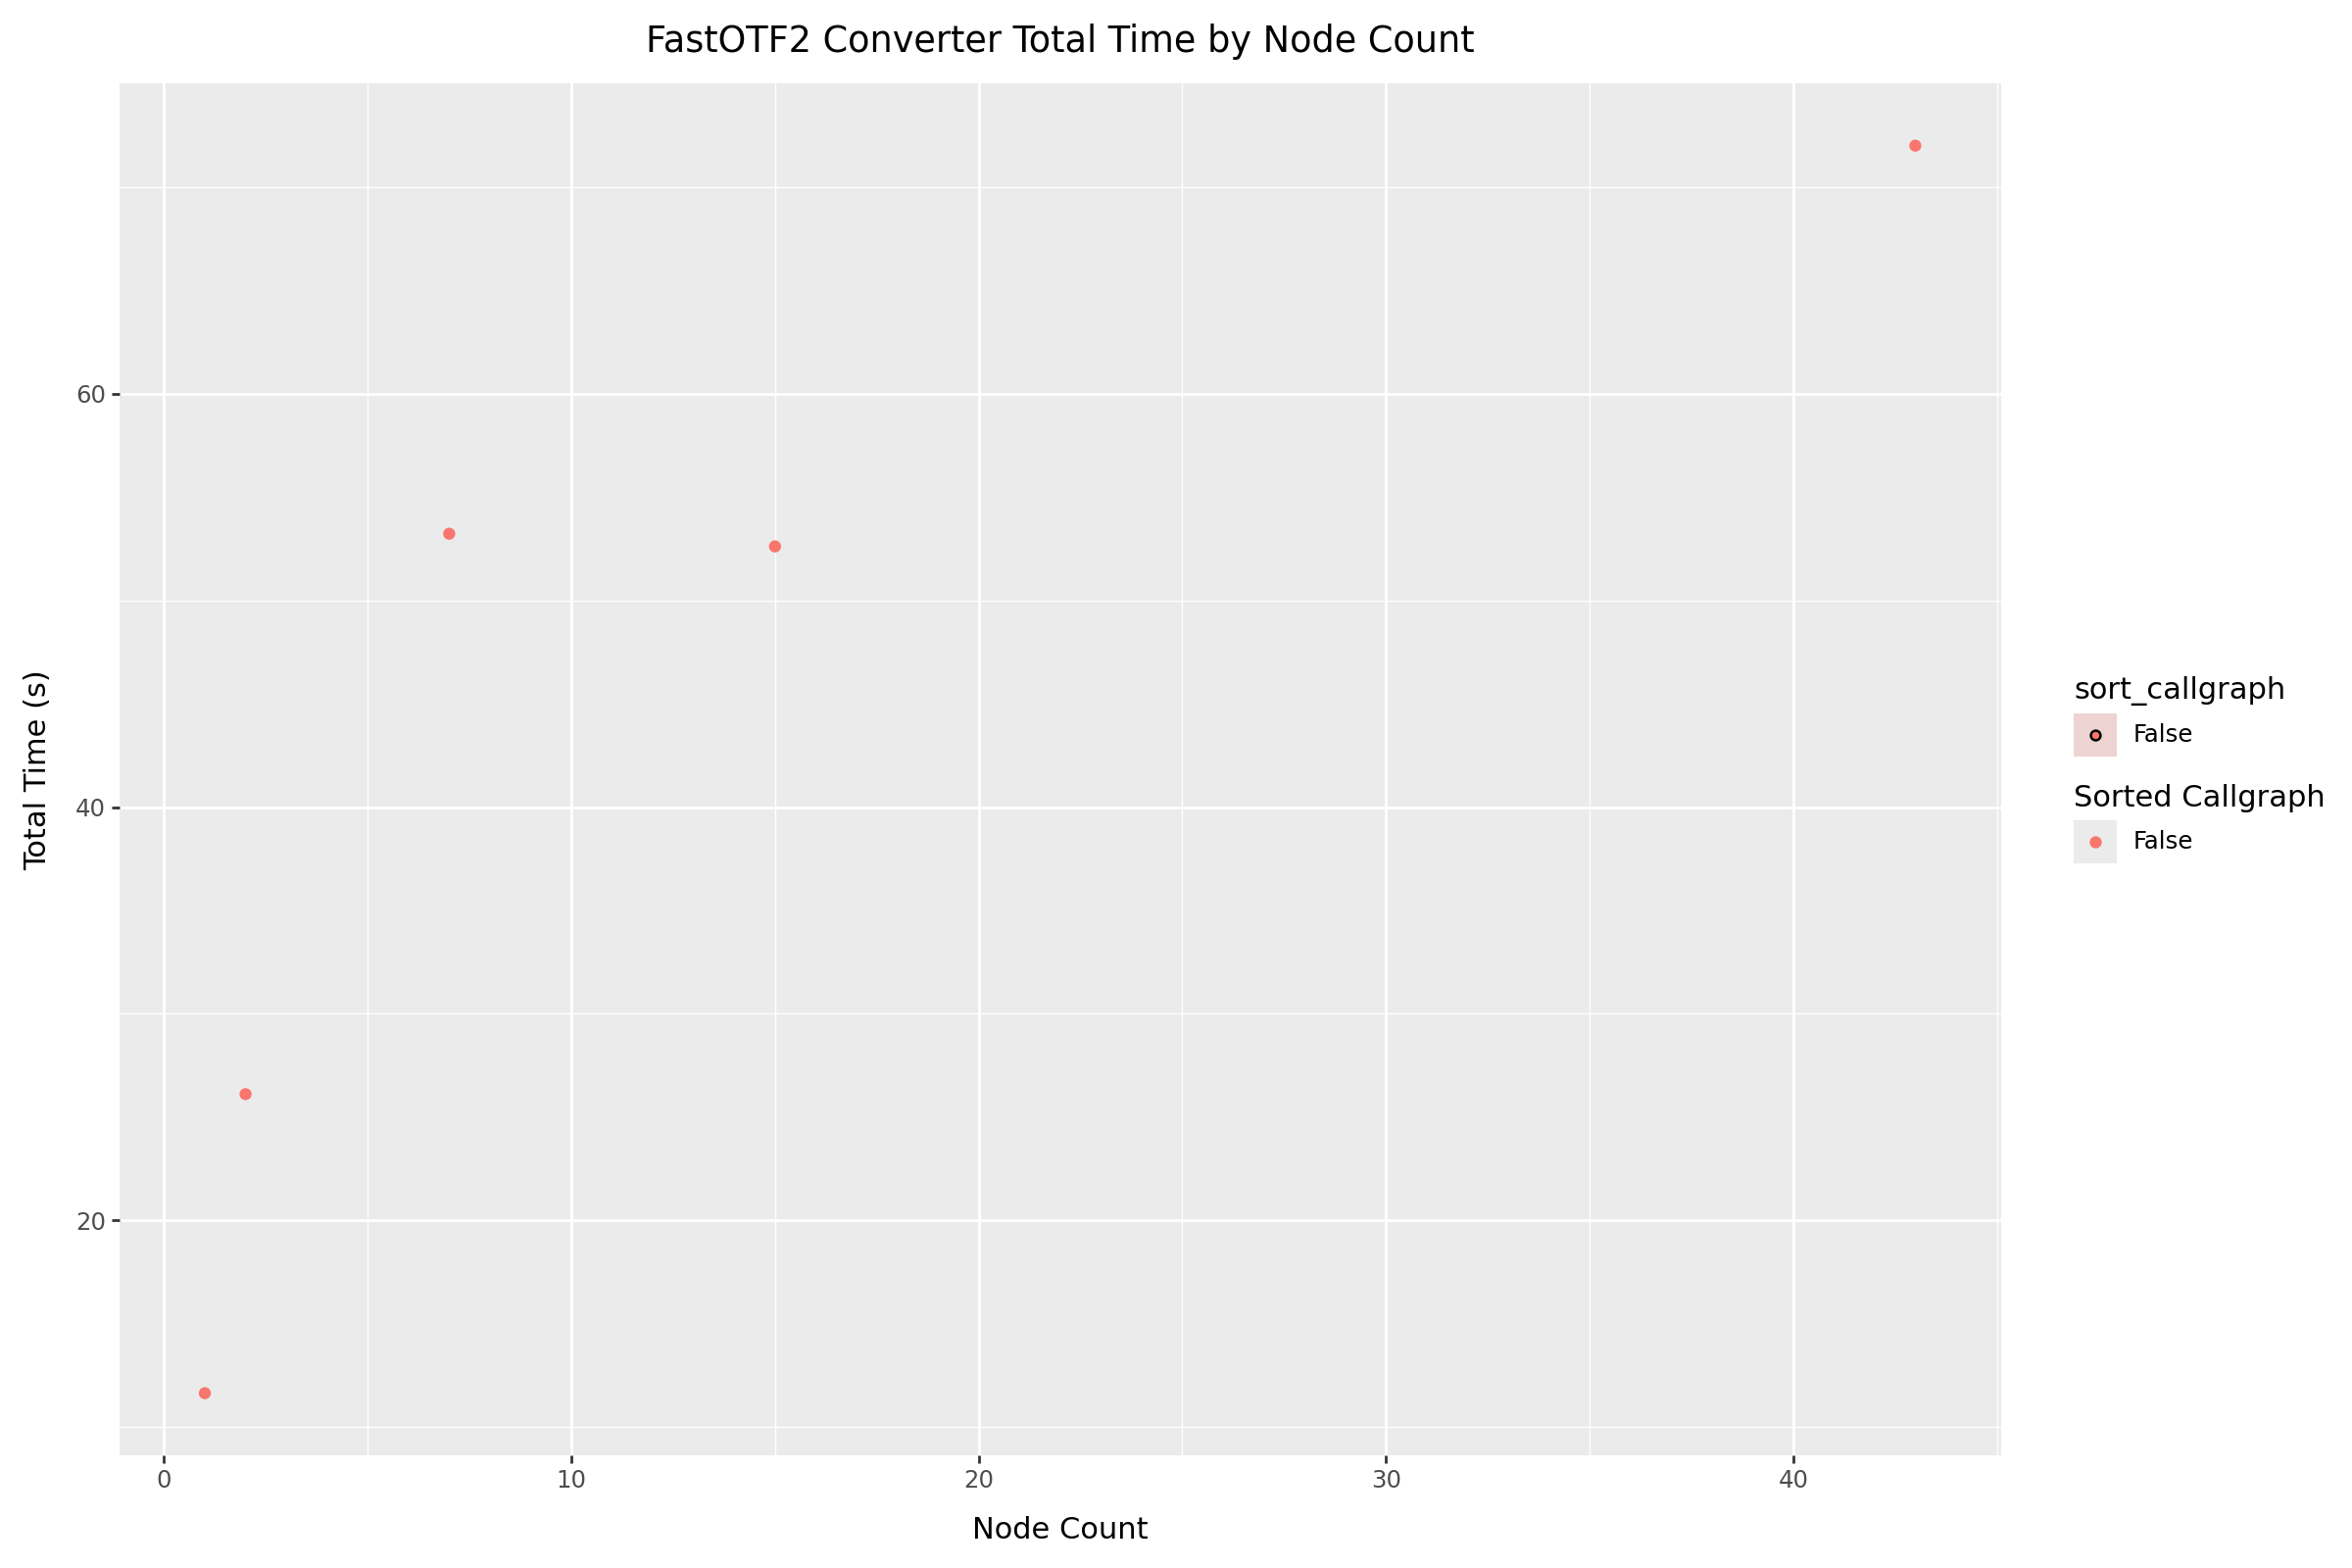

In [68]:
p = ggplot(df_range, aes(x='node_count', y='total_time_s', fill='sort_callgraph', color='sort_callgraph'))
p += geom_ribbon(aes(ymin='min_time', ymax='max_time', fill='sort_callgraph'), alpha=0.2, color=None)
p += geom_point()
p += labs(title='FastOTF2 Converter Total Time by Node Count', x='Node Count', y='Total Time (s)', color='Sorted Callgraph')
p += theme(figure_size=(12,8))
p

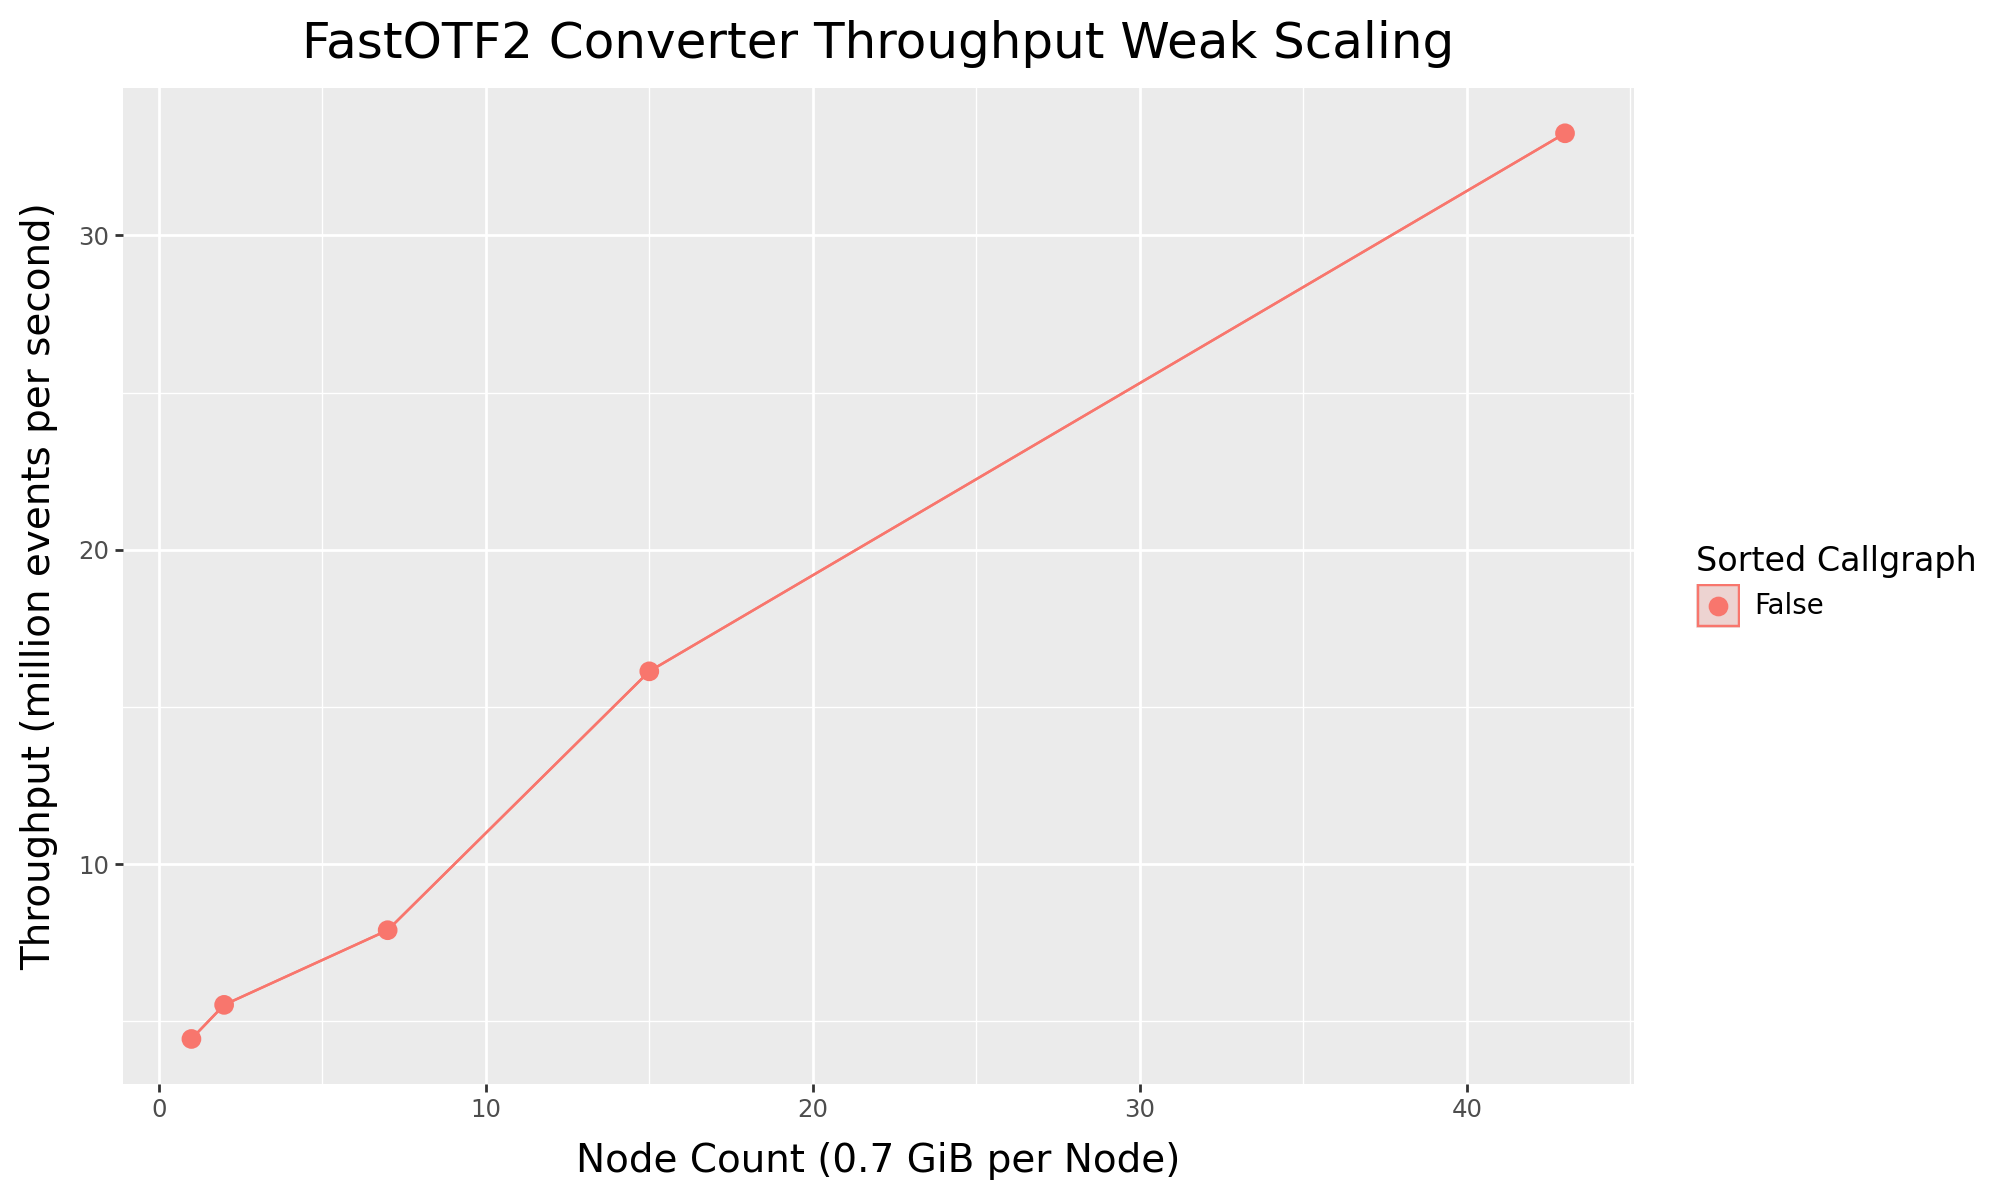

In [70]:
df_range = df.groupby(['node_count', 'sort_callgraph'])['throughput_eps'].agg(['min', 'max', 'mean']).reset_index()
df_range.rename(columns={'min': 'min_throughput', 'max': 'max_throughput', 'mean': 'throughput_eps'}, inplace=True)

df['throughput_Meps'] = df['throughput_eps'] / 1000000.0
df_range['throughput_Meps'] = df_range['throughput_eps'] / 1000000.0
df_range['min_throughput_Meps'] = df_range['min_throughput'] / 1000000.0
df_range['max_throughput_Meps'] = df_range['max_throughput'] / 1000000.0

p = ggplot(df_range, aes(x='node_count', y='throughput_Meps', color='sort_callgraph', fill='sort_callgraph', shape='sort_callgraph'))
p += geom_ribbon(aes(ymin='min_throughput_Meps', ymax='max_throughput_Meps', fill='sort_callgraph'), alpha=0.2)
p += geom_point(size=3)
p += labs(title='FastOTF2 Converter Throughput Weak Scaling', x=f'Node Count ({gib_per_node} GiB per Node)', 
          y='Throughput (million events per second)', color='Sorted Callgraph', 
          fill='Sorted Callgraph', shape='Sorted Callgraph')
# make it slightly bigger
p += theme(figure_size=(10,6), title=element_text(size=18), axis_title=element_text(size=14), 
           legend_title=element_text(size=12), legend_text=element_text(size=10))
p